In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df=pd.read_csv('netflix_titles.csv')

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [6]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [7]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
df['director']=df['director'].fillna('Director name is not specified')
df['cast']=df['cast'].fillna('Cast not specified')
df['country']=df['country'].fillna('Missing')
df['date_added']=df['date_added'].fillna('Missing')
df['rating']=df['rating'].fillna('Not specified')
df['duration']=df['duration'].fillna('Missing')

In [9]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [10]:
df.head(5)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Cast not specified,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Director name is not specified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Missing,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Director name is not specified,Cast not specified,Missing,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Director name is not specified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [11]:
df.columns=df.columns.str.upper().str.replace('_',' ',regex=True).str.strip()

In [12]:
df.columns

Index(['SHOW ID', 'TYPE', 'TITLE', 'DIRECTOR', 'CAST', 'COUNTRY', 'DATE ADDED',
       'RELEASE YEAR', 'RATING', 'DURATION', 'LISTED IN', 'DESCRIPTION'],
      dtype='str')

In [13]:
df.to_csv('cleaned_netflix_titles.csv',index=False)

Top 8 Ratings Distribution

In [14]:
rating_counts=df['RATING'].value_counts().head(10)

In [15]:
rating_counts

RATING
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64

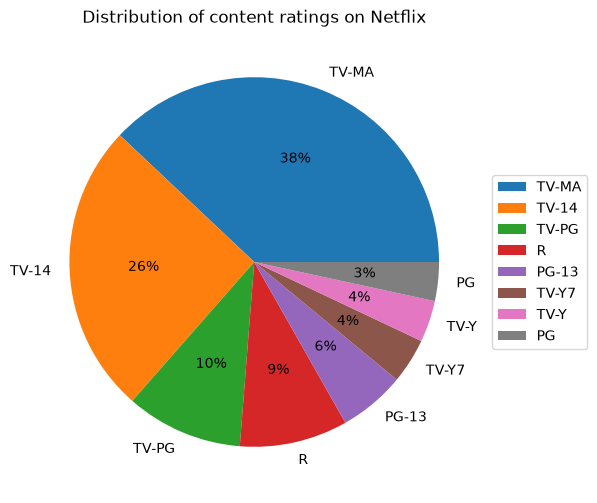

In [16]:
rating_counts=df['RATING'].value_counts().head(8)
plt.figure(figsize=(6,6))
plt.pie(rating_counts.values,labels=rating_counts.index,autopct='%1.0f%%')
plt.legend(loc="center left",bbox_to_anchor=(1,0.5))
plt.title("Distribution of content ratings on Netflix")
plt.show()

Rating insights
-The rating distribution shows that 38% has the largest share among top 8 ratings, indicating that it is one of the most common content ratings  on Netflix.

Analyzing the Top 5 directors on Netflix

In [17]:
director_list=pd.DataFrame()
print(director_list)

Empty DataFrame
Columns: []
Index: []


In [18]:
director_list=df['DIRECTOR'].str.split(',').explode()
print(director_list)

0                      Kirsten Johnson
1       Director name is not specified
2                      Julien Leclercq
3       Director name is not specified
4       Director name is not specified
                     ...              
8802                     David Fincher
8803    Director name is not specified
8804                   Ruben Fleischer
8805                      Peter Hewitt
8806                       Mozez Singh
Name: DIRECTOR, Length: 9612, dtype: str


In [19]:
director_list=director_list.to_frame()
print(director_list)

                            DIRECTOR
0                    Kirsten Johnson
1     Director name is not specified
2                    Julien Leclercq
3     Director name is not specified
4     Director name is not specified
...                              ...
8802                   David Fincher
8803  Director name is not specified
8804                 Ruben Fleischer
8805                    Peter Hewitt
8806                     Mozez Singh

[9612 rows x 1 columns]


In [20]:
director_list.columns=['DIRECTOR']
print(director_list)

                            DIRECTOR
0                    Kirsten Johnson
1     Director name is not specified
2                    Julien Leclercq
3     Director name is not specified
4     Director name is not specified
...                              ...
8802                   David Fincher
8803  Director name is not specified
8804                 Ruben Fleischer
8805                    Peter Hewitt
8806                     Mozez Singh

[9612 rows x 1 columns]


In [21]:
director=director_list.groupby(['DIRECTOR']).size().reset_index(name='Total count')
print(director)

                       DIRECTOR  Total count
0                Aaron Moorhead            2
1                   Aaron Woolf            1
2      Abbas Alibhai Burmawalla            1
3              Abdullah Al Noor            1
4           Abhinav Shiv Tiwari            1
...                         ...          ...
5116                Çagan Irmak            1
5117           Ísold Uggadóttir            1
5118        Óskar Thór Axelsson            1
5119           Ömer Faruk Sorak            2
5120               Şenol Sönmez            2

[5121 rows x 2 columns]


In [22]:
directors=director[director.DIRECTOR !='Director name is not specified']
print(directors)

                       DIRECTOR  Total count
0                Aaron Moorhead            2
1                   Aaron Woolf            1
2      Abbas Alibhai Burmawalla            1
3              Abdullah Al Noor            1
4           Abhinav Shiv Tiwari            1
...                         ...          ...
5116                Çagan Irmak            1
5117           Ísold Uggadóttir            1
5118        Óskar Thór Axelsson            1
5119           Ömer Faruk Sorak            2
5120               Şenol Sönmez            2

[5120 rows x 2 columns]


In [23]:
directors=directors.sort_values(by=['Total count'],ascending=False)
print(directors)

                 DIRECTOR  Total count
4021        Rajiv Chilaka           22
4068          Raúl Campos           18
261             Jan Suter           18
3236         Marcus Raboy           16
4652          Suhas Kadav           16
...                   ...          ...
5116          Çagan Irmak            1
5117     Ísold Uggadóttir            1
5118  Óskar Thór Axelsson            1
2536           Jesse Moss            1
4480         Shazia Javed            1

[5120 rows x 2 columns]


In [24]:
top5_directors=directors.head()
print(top5_directors)

           DIRECTOR  Total count
4021  Rajiv Chilaka           22
4068    Raúl Campos           18
261       Jan Suter           18
3236   Marcus Raboy           16
4652    Suhas Kadav           16


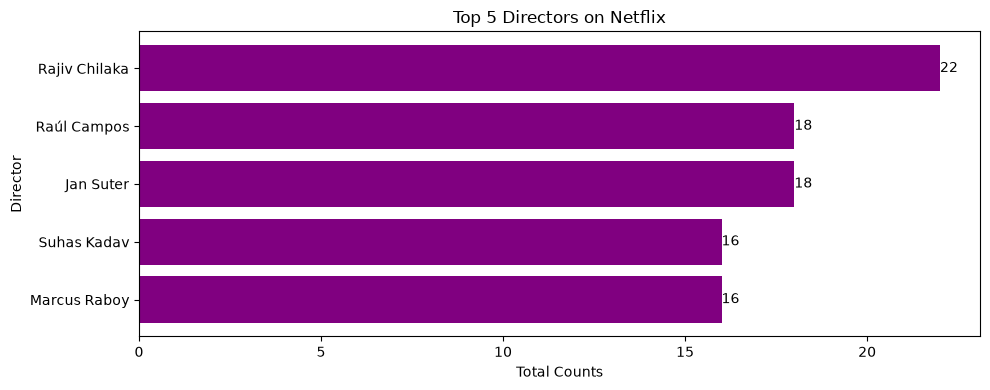

In [25]:
top5_directors=top5_directors.sort_values(by=['Total count'])
plt.figure(figsize=(10,4))
bars=plt.barh(top5_directors['DIRECTOR'],top5_directors['Total count'],color="purple")
plt.bar_label(bars)
plt.title('Top 5 Directors on Netflix')
plt.xlabel('Total Counts')
plt.ylabel('Director')
plt.tight_layout()
plt.show()

Insights
- The analysis shows that Rajiv chilaka has highest number of titles among the top 5 directors,indicating a significant contribution to Netflix's content library.

Top 5 Actors on Netflix

In [26]:
cast_df=pd.DataFrame()

In [27]:
cast_df=(df['CAST'].str.split(",").explode())
cast_df=cast_df.to_frame()
cast_df.columns=['ACTOR']
actors=cast_df.groupby(['ACTOR']).size().reset_index(name='Total count')
actors=actors[actors.ACTOR!='Cast not specified']
actors=actors.sort_values(by=['Total count'],ascending=False)




In [28]:
top5_actors=actors.head()
top5_actors=top5_actors.sort_values(by=['Total count'])

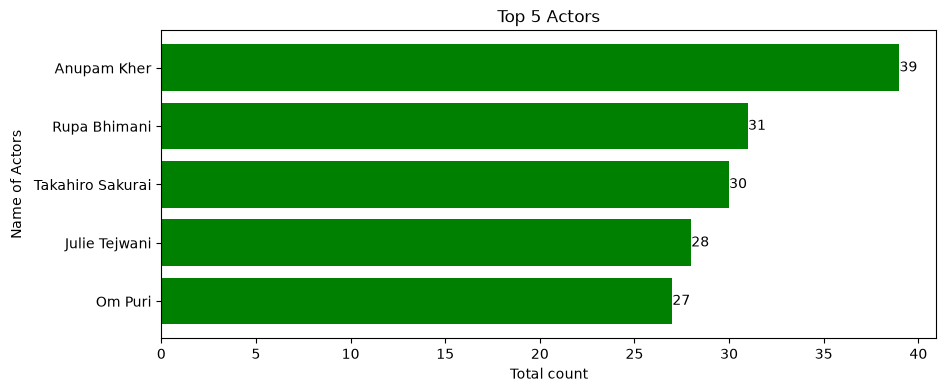

In [29]:
plt.figure(figsize=(10,4))
bars=plt.barh(top5_actors['ACTOR'],top5_actors['Total count'],color='green')
plt.bar_label(bars)
plt.title('Top 5 Actors')
plt.xlabel('Total count')
plt.ylabel('Name of Actors')
plt.show()

Insights: Anupam kher has the highest number of appearences among  the top 5 actors,showing a strong presense in Netflix's content library.

Analyzing the content produced on netflix based on years

In [30]:
df1=df[['TYPE','RELEASE YEAR']]
df2=df1.groupby(['TYPE','RELEASE YEAR']).size().reset_index(name='Total count')

In [31]:
print(df2)

        TYPE  RELEASE YEAR  Total count
0      Movie          1942            2
1      Movie          1943            3
2      Movie          1944            3
3      Movie          1945            3
4      Movie          1946            1
..       ...           ...          ...
114  TV Show          2017          265
115  TV Show          2018          380
116  TV Show          2019          397
117  TV Show          2020          436
118  TV Show          2021          315

[119 rows x 3 columns]


In [32]:
year_counts=df[df['RELEASE YEAR']>=2000]['RELEASE YEAR'].value_counts().sort_index()
print(year_counts)

RELEASE YEAR
2000      37
2001      45
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64


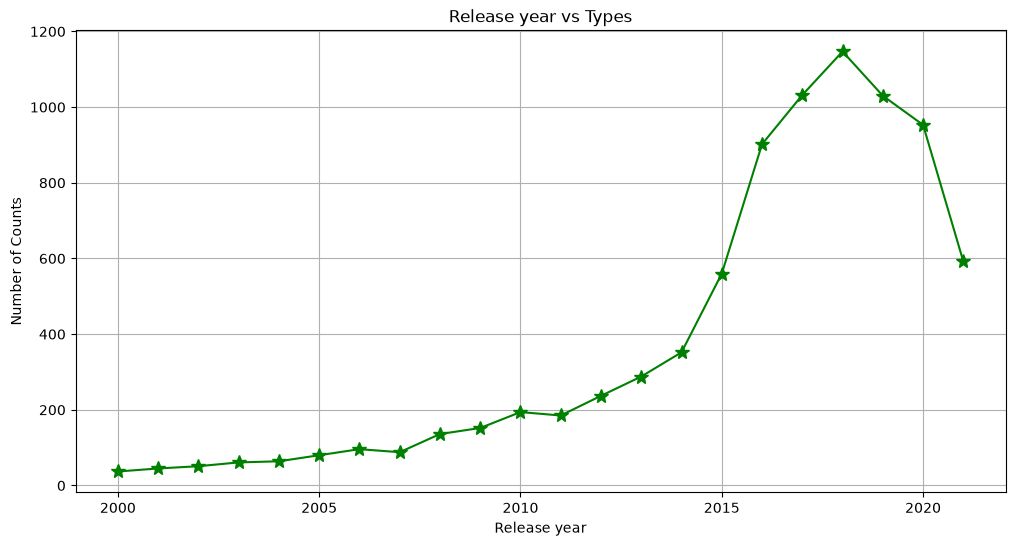

In [33]:
plt.figure(figsize=(12,6))
plt.plot(year_counts.index,year_counts.values, marker='*',ms=10,color='green')
plt.title('Release year vs Types')
plt.grid()
plt.xlabel('Release year')
plt.ylabel('Number of Counts')
plt.show()

Insights

-From the year-wise analysis,2018 had a highest number of content produced on Netflix,inducating a major expansion of it's content library.